# Análise Exploratória de Dados — corpus PubMed

**RES IA ELD UnB — Turma 1 | Grupo 08**

**Integrantes:** Victor Barbosa da Silva; Keila Alves Ferreira; Thayná Gonçalves Dutra; João Vitor Carvalho Barbosa; Vinícius César Sena Torres; Ketlyn Karen Silva de Morais.

## tl;dr

Foram analisados **100 dos 116 registros** retornados pelo PubMed (**86,2% de cobertura**). O snapshot não possui PMIDs ou títulos duplicados, todos os registros têm ano e URL, **93% têm DOI** e dois não informam autores. A amostra cobre **1964–2026** e está distribuída entre muitos periódicos: os dez mais frequentes concentram 38% dos artigos.

A triagem textual mostra que 39 títulos mencionam simultaneamente café e próstata, enquanto 12 não mencionam nenhum dos conceitos no título. Isso não prova irrelevância — a correspondência pode estar no resumo ou nos termos MeSH —, mas demonstra a necessidade de filtrar o corpus antes do RAG.

O corpus é apropriado como fonte documental do pipeline de recuperação de evidências. Ele **não contém rótulos de fake news** e, isoladamente, não permite treinar nem avaliar um classificador supervisionado de veracidade.

## Contexto e métodos

### Objetivo

Compreender o conjunto de artigos científicos que alimentará o MVP Fato ou Fake, avaliando cobertura, qualidade dos metadados, distribuição temporal, concentração por periódico e características textuais dos títulos.

### Unidade de análise e fonte

- **Grão:** um registro bibliográfico por PMID.
- **Fonte oficial:** PubMed, por meio das E-utilities do NCBI.
- **Consulta:** combinação de termos MeSH e termos em título/resumo para café e câncer de próstata.
- **Amostra:** até 100 registros ordenados por relevância pelo PubMed.
- **Snapshot:** salvo em `data/pubmed_cafe_cancer_prostata.csv`, acompanhado dos metadados da coleta.

### Premissas e limitações

- A amostra por relevância não representa todo o PubMed nem permite inferências epidemiológicas.
- Ausência de DOI pode ser legítima e não significa necessariamente erro.
- Títulos são analisados como texto disponível; esta EDA não substitui a análise de resumos ou textos completos.
- Frequência de termos indica temas recorrentes, não apoio ou contradição da alegação.
- A consulta e o ranking do PubMed podem mudar em coletas futuras; o snapshot preserva esta execução.

In [1]:
from collections import Counter
from datetime import datetime, timezone
from io import BytesIO
from pathlib import Path
from statistics import mean, median
import base64
import csv
import json
import os
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / 'src'))

from fatofake import PubMedClient, SearchPlan, search_pubmed

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'primary': '#35618f', 'secondary': '#d8a62a', 'neutral': '#697386'}


def display_figure(fig, alt_text: str) -> None:
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=140, bbox_inches='tight')
    encoded = base64.b64encode(buffer.getvalue()).decode('ascii')
    display(HTML(
        f'<img alt="{alt_text}" src="data:image/png;base64,{encoded}" '
        'style="max-width:100%;">'
    ))
    plt.close(fig)


print(f'Execução UTC: {datetime.now(timezone.utc).isoformat()}')

Execução UTC: 2026-09-28T11:51:13.975065+00:00


## Dados

### 1. Definir a consulta e carregar o snapshot

Por padrão, o notebook reutiliza o snapshot salvo. Para atualizar a coleta, altere `REFRESH_DATA` para `True`.

In [2]:
QUERY = (
    '("Coffee"[MeSH Terms] OR coffee[Title/Abstract]) AND '
    '("Prostatic Neoplasms"[MeSH Terms] OR "prostate cancer"[Title/Abstract])'
)
MAX_RECORDS = 100
REFRESH_DATA = False

data_dir = project_root / 'data'
data_dir.mkdir(exist_ok=True)
csv_path = data_dir / 'pubmed_cafe_cancer_prostata.csv'
metadata_path = data_dir / 'pubmed_cafe_cancer_prostata_metadata.json'


def extract_year(value: str) -> int | None:
    match = re.search(r'\b(18|19|20)\d{2}\b', value or '')
    return int(match.group()) if match else None


if REFRESH_DATA or not csv_path.exists() or not metadata_path.exists():
    plan = SearchPlan(
        claim='Beber café pode alterar o risco de câncer de próstata.',
        queries=(QUERY,),
    )
    result = search_pubmed(
        plan,
        PubMedClient(email=os.getenv('NCBI_EMAIL'), api_key=os.getenv('NCBI_API_KEY')),
        max_results_per_query=MAX_RECORDS,
    )
    rows = [
        {
            'pmid': publication.pmid,
            'title': publication.title,
            'journal': publication.journal or '',
            'publication_date': publication.publication_date or '',
            'year': extract_year(publication.publication_date or '') or '',
            'author_count': len(publication.authors),
            'first_author': publication.authors[0] if publication.authors else '',
            'doi': publication.doi or '',
            'url': publication.url,
        }
        for publication in result.publications
    ]
    metadata = {
        'source': 'PubMed / NCBI E-utilities',
        'source_url': 'https://pubmed.ncbi.nlm.nih.gov/',
        'query': QUERY,
        'sort': 'relevance',
        'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
        'total_matches': result.query_results[0].total_matches,
        'records_captured': len(rows),
        'max_records': MAX_RECORDS,
    }
    with csv_path.open('w', encoding='utf-8', newline='') as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
    metadata_path.write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2) + '\n', encoding='utf-8'
    )
else:
    with csv_path.open(encoding='utf-8', newline='') as handle:
        rows = list(csv.DictReader(handle))
    for row in rows:
        row['year'] = int(row['year']) if row['year'] else ''
        row['author_count'] = int(row['author_count'])
    metadata = json.loads(metadata_path.read_text(encoding='utf-8'))

coverage = len(rows) / metadata['total_matches'] if metadata['total_matches'] else 0
print(json.dumps(metadata, ensure_ascii=False, indent=2))
print(f'Cobertura da consulta: {len(rows)}/{metadata["total_matches"]} ({coverage:.1%})')

{
  "source": "PubMed / NCBI E-utilities",
  "source_url": "https://pubmed.ncbi.nlm.nih.gov/",
  "query": "(\"Coffee\"[MeSH Terms] OR coffee[Title/Abstract]) AND (\"Prostatic Neoplasms\"[MeSH Terms] OR \"prostate cancer\"[Title/Abstract])",
  "sort": "relevance",
  "retrieved_at_utc": "2026-09-28T11:45:37.295122+00:00",
  "total_matches": 116,
  "records_captured": 100,
  "max_records": 100
}
Cobertura da consulta: 100/116 (86.2%)


### 2. Inspecionar estrutura e exemplos

A tabela abaixo apresenta apenas cinco registros para manter a saída legível. URLs e PMIDs preservam a rastreabilidade até a fonte.

In [3]:
columns = list(rows[0])
print(f'Formato: {len(rows)} linhas × {len(columns)} colunas')
print('Colunas:', ', '.join(columns))
print()
for row in rows[:5]:
    print({
        'pmid': row['pmid'],
        'year': row['year'],
        'journal': row['journal'],
        'title': row['title'][:100],
        'url': row['url'],
    })

Formato: 100 linhas × 9 colunas
Colunas: pmid, title, journal, publication_date, year, author_count, first_author, doi, url

{'pmid': '3855486', 'year': 1985, 'journal': 'Journal of the National Cancer Institute', 'title': 'Early precursors of site-specific cancers in college men and women.', 'url': 'https://pubmed.ncbi.nlm.nih.gov/3855486/'}
{'pmid': '33977254', 'year': 2021, 'journal': 'IJU case reports', 'title': 'Trocar site hernia resulting in intestinal necrosis 48\xa0hours after robot-assisted radical prostatect', 'url': 'https://pubmed.ncbi.nlm.nih.gov/33977254/'}
{'pmid': '14166832', 'year': 1964, 'journal': 'The Tohoku journal of experimental medicine', 'title': 'COFFEE CONSUMPTION AND MORTALITY FOR PROSTATE CANCER.', 'url': 'https://pubmed.ncbi.nlm.nih.gov/14166832/'}
{'pmid': '21991610', 'year': 2011, 'journal': 'Harvard heart letter : from Harvard Medical School', 'title': 'Research continues to serve up heart perks for coffee drinkers.', 'url': 'https://pubmed.ncbi.nlm.ni

## Resultados

### 3. Qualidade dos dados

São avaliadas completude, unicidade, validade básica e possíveis duplicatas textuais. DOI é opcional; sua ausência é reportada como limitação de interoperabilidade, não como registro inválido.

In [4]:
def normalize_title(value: str) -> str:
    return re.sub(r'[^a-z0-9]+', ' ', value.casefold()).strip()


missing_counts = {
    column: sum(not str(row[column]).strip() for row in rows)
    for column in columns
}
completeness = {
    column: 1 - missing_counts[column] / len(rows)
    for column in columns
}
pmid_counts = Counter(row['pmid'] for row in rows)
title_counts = Counter(normalize_title(row['title']) for row in rows if row['title'])
duplicate_pmids = sum(count - 1 for count in pmid_counts.values() if count > 1)
duplicate_titles = sum(count - 1 for count in title_counts.values() if count > 1)
current_year = datetime.now(timezone.utc).year
invalid_years = [
    row for row in rows
    if row['year'] and not 1800 <= int(row['year']) <= current_year
]
invalid_urls = [row for row in rows if not row['url'].startswith('https://pubmed.ncbi.nlm.nih.gov/')]

quality_summary = {
    'rows': len(rows),
    'columns': len(columns),
    'duplicate_pmids': duplicate_pmids,
    'duplicate_normalized_titles': duplicate_titles,
    'missing_publication_year': missing_counts['year'],
    'missing_doi': missing_counts['doi'],
    'records_without_authors': sum(row['author_count'] == 0 for row in rows),
    'invalid_years': len(invalid_years),
    'invalid_pubmed_urls': len(invalid_urls),
}
print(json.dumps(quality_summary, ensure_ascii=False, indent=2))

{
  "rows": 100,
  "columns": 9,
  "duplicate_pmids": 0,
  "duplicate_normalized_titles": 0,
  "missing_publication_year": 0,
  "missing_doi": 7,
  "records_without_authors": 2,
  "invalid_years": 0,
  "invalid_pubmed_urls": 0
}



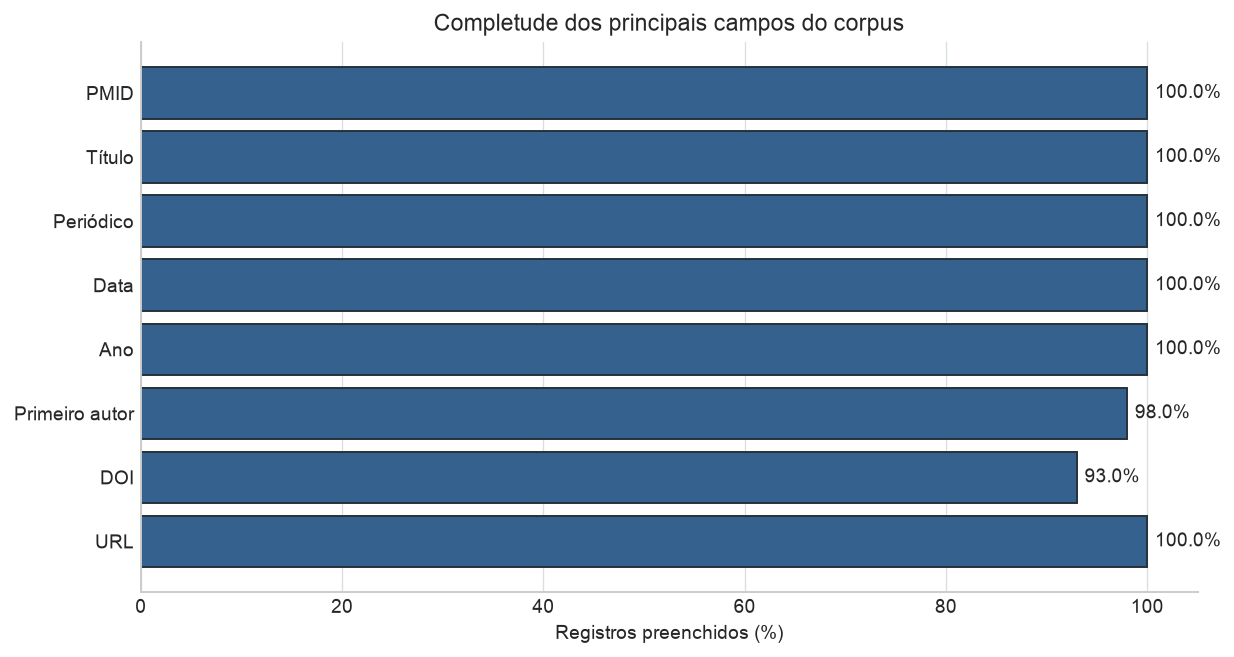

In [5]:
fields_to_plot = ['pmid', 'title', 'journal', 'publication_date', 'year', 'first_author', 'doi', 'url']
labels = ['PMID', 'Título', 'Periódico', 'Data', 'Ano', 'Primeiro autor', 'DOI', 'URL']
values = [completeness[field] * 100 for field in fields_to_plot]

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(labels[::-1], values[::-1], color=COLORS['primary'], edgecolor='#263238')
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_xlim(0, 105)
ax.set_xlabel('Registros preenchidos (%)')
ax.set_title('Completude dos principais campos do corpus')
ax.grid(axis='x', color='#d9dee3', linewidth=0.7)
ax.grid(axis='y', visible=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
display_figure(fig, 'Completude percentual dos principais campos do corpus.')

### 4. Triagem temática aproximada pelos títulos

Como diagnóstico de precisão da busca, os títulos são separados conforme mencionam café e próstata. Essa é apenas uma triagem: artigos recuperados por resumo ou MeSH podem ser relevantes mesmo sem trazer os dois conceitos no título. Registros sem nenhum conceito no título merecem revisão antes de entrar no RAG.


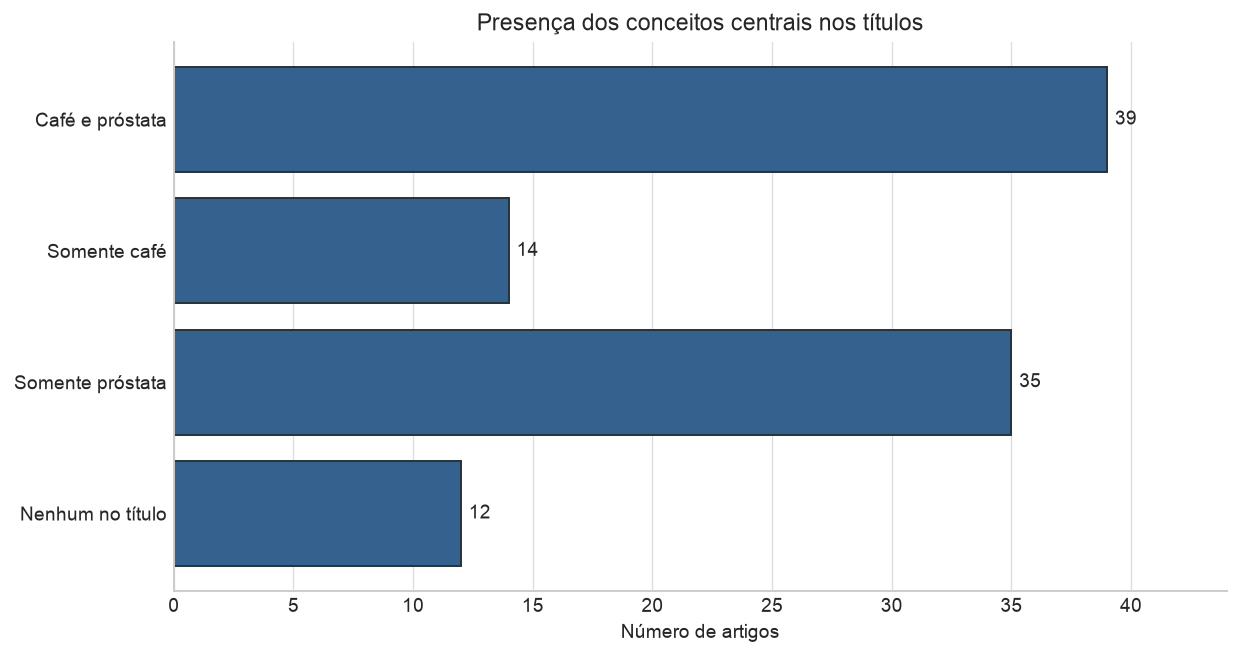

{'Nenhum no título': 12, 'Somente próstata': 35, 'Café e próstata': 39, 'Somente café': 14}
A ausência no título é um sinal para triagem, não uma prova de irrelevância.


In [6]:
def title_topic_group(title: str) -> str:
    normalized = title.casefold()
    mentions_coffee = bool(re.search(r'\bcoffee\b|\bcaffeine\b', normalized))
    mentions_prostate = bool(re.search(r'\bprostat', normalized))
    if mentions_coffee and mentions_prostate:
        return 'Café e próstata'
    if mentions_coffee:
        return 'Somente café'
    if mentions_prostate:
        return 'Somente próstata'
    return 'Nenhum no título'


topic_order = ['Café e próstata', 'Somente café', 'Somente próstata', 'Nenhum no título']
title_topic_counts = Counter(title_topic_group(row['title']) for row in rows)
topic_values = [title_topic_counts[label] for label in topic_order]

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(topic_order[::-1], topic_values[::-1], color=COLORS['primary'], edgecolor='#263238')
ax.bar_label(bars, padding=4)
ax.set_title('Presença dos conceitos centrais nos títulos')
ax.set_xlabel('Número de artigos')
ax.set_xlim(0, max(topic_values) + 5)
ax.grid(axis='x', color='#d9dee3', linewidth=0.7)
ax.grid(axis='y', visible=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
display_figure(
    fig, 'Artigos cujos títulos mencionam café, próstata, ambos ou nenhum.'
)

print(dict(title_topic_counts))
print('A ausência no título é um sinal para triagem, não uma prova de irrelevância.')

### 5. Distribuição temporal

O gráfico mostra a quantidade de registros por ano de publicação. Anos sem registros na amostra são representados explicitamente por zero, evitando ligar períodos não consecutivos como se fossem uma série contínua.


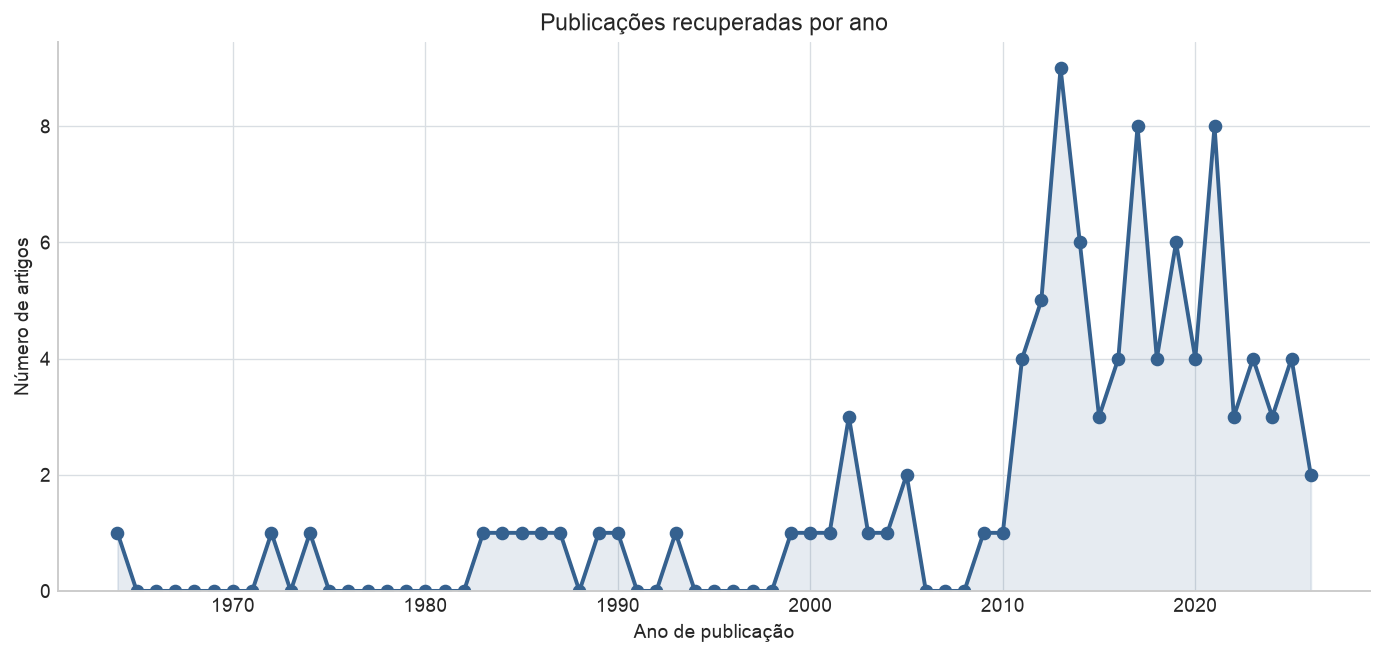

Período observado: 1964–2026.
Ano com mais registros na amostra: 2013 (9).


In [7]:
year_counts = Counter(int(row['year']) for row in rows if row['year'])
years = list(range(min(year_counts), max(year_counts) + 1)) if year_counts else []
counts_by_year = [year_counts[year] for year in years]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(years, counts_by_year, color=COLORS['primary'], marker='o', linewidth=2)
ax.fill_between(years, counts_by_year, color=COLORS['primary'], alpha=0.12)
ax.set_title('Publicações recuperadas por ano')
ax.set_xlabel('Ano de publicação')
ax.set_ylabel('Número de artigos')
ax.set_ylim(bottom=0)
ax.grid(color='#d9dee3', linewidth=0.7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
display_figure(fig, 'Quantidade de publicações recuperadas por ano entre 1964 e 2026.')

if years:
    print(f'Período observado: {min(years)}–{max(years)}.')
    print(f'Ano com mais registros na amostra: {max(year_counts, key=year_counts.get)} ({max(year_counts.values())}).')

### 6. Concentração por periódico

Os dez periódicos mais frequentes ajudam a identificar concentração editorial. As contagens descrevem apenas a amostra recuperada, sem representar qualidade ou impacto científico.


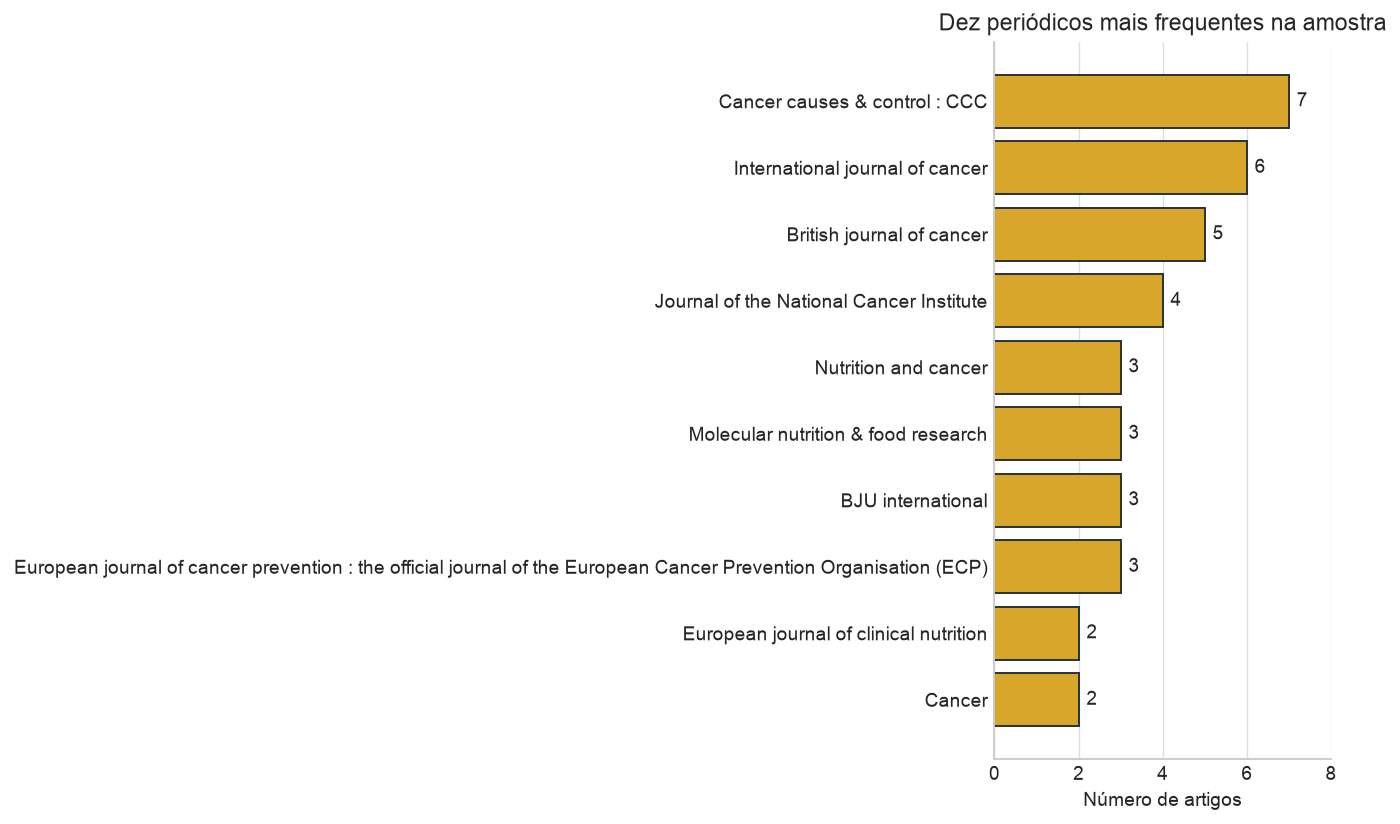

Os dez periódicos mais frequentes concentram 38.0% da amostra.


In [8]:
journal_counts = Counter(row['journal'] or 'Não informado' for row in rows)
top_journals = journal_counts.most_common(10)
names = [name for name, _ in top_journals][::-1]
values = [count for _, count in top_journals][::-1]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(names, values, color=COLORS['secondary'], edgecolor='#263238')
ax.bar_label(bars, padding=4)
ax.set_title('Dez periódicos mais frequentes na amostra')
ax.set_xlabel('Número de artigos')
ax.set_xlim(0, max(values) + 1)
ax.grid(axis='x', color='#d9dee3', linewidth=0.7)
ax.grid(axis='y', visible=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
display_figure(fig, 'Dez periódicos mais frequentes na amostra.')

top_10_share = sum(values) / len(rows)
print(f'Os dez periódicos mais frequentes concentram {top_10_share:.1%} da amostra.')

### 7. Características textuais dos títulos

O primeiro gráfico avalia o tamanho dos títulos. O segundo mostra os termos informativos mais frequentes após normalização simples e remoção de palavras funcionais. Esta contagem não mede relevância clínica nem direção da evidência.

{
  "minimum_words": 5,
  "median_words": 14.0,
  "mean_words": 14.1,
  "p75_words": 17.0,
  "maximum_words": 28
}



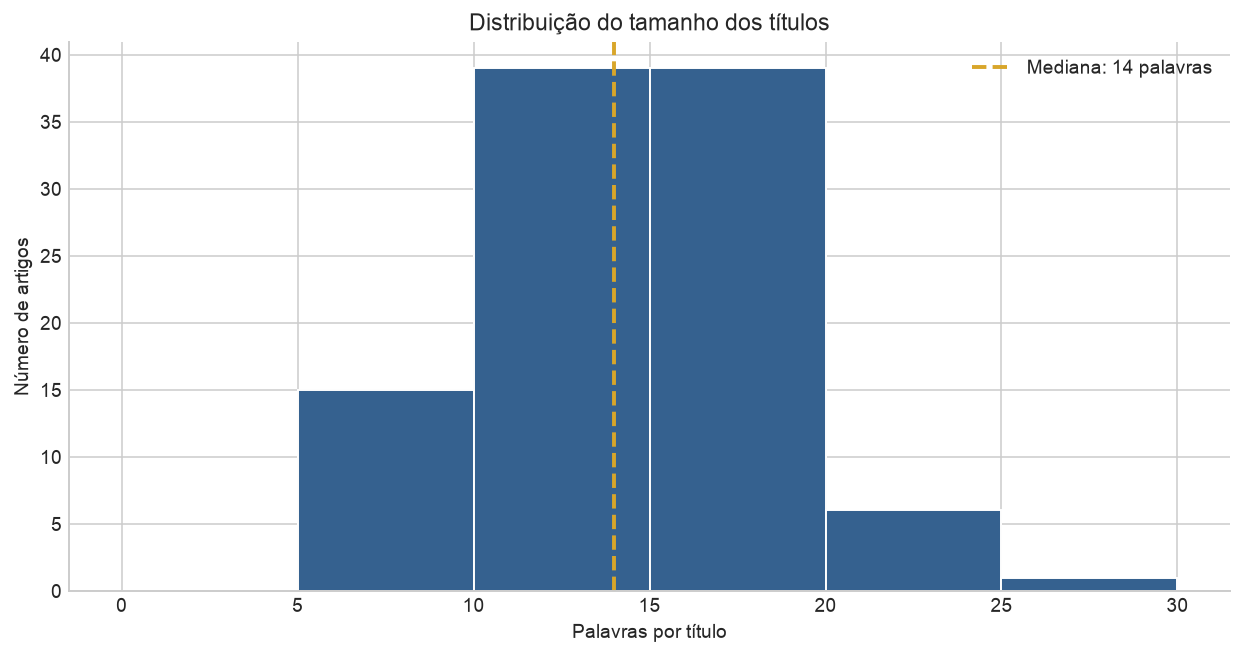

In [9]:
title_lengths = [len(re.findall(r"[A-Za-z0-9]+", row['title'])) for row in rows]
length_summary = {
    'minimum_words': min(title_lengths),
    'median_words': median(title_lengths),
    'mean_words': round(mean(title_lengths), 1),
    'p75_words': float(np.percentile(title_lengths, 75)),
    'maximum_words': max(title_lengths),
}
print(json.dumps(length_summary, ensure_ascii=False, indent=2))

fig, ax = plt.subplots(figsize=(9, 4.8))
bins = range(0, max(title_lengths) + 5, 5)
ax.hist(title_lengths, bins=bins, color=COLORS['primary'], edgecolor='white')
ax.axvline(median(title_lengths), color=COLORS['secondary'], linestyle='--', linewidth=2,
           label=f'Mediana: {median(title_lengths):.0f} palavras')
ax.set_title('Distribuição do tamanho dos títulos')
ax.set_xlabel('Palavras por título')
ax.set_ylabel('Número de artigos')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
display_figure(fig, 'Distribuição do número de palavras por título e sua mediana.')


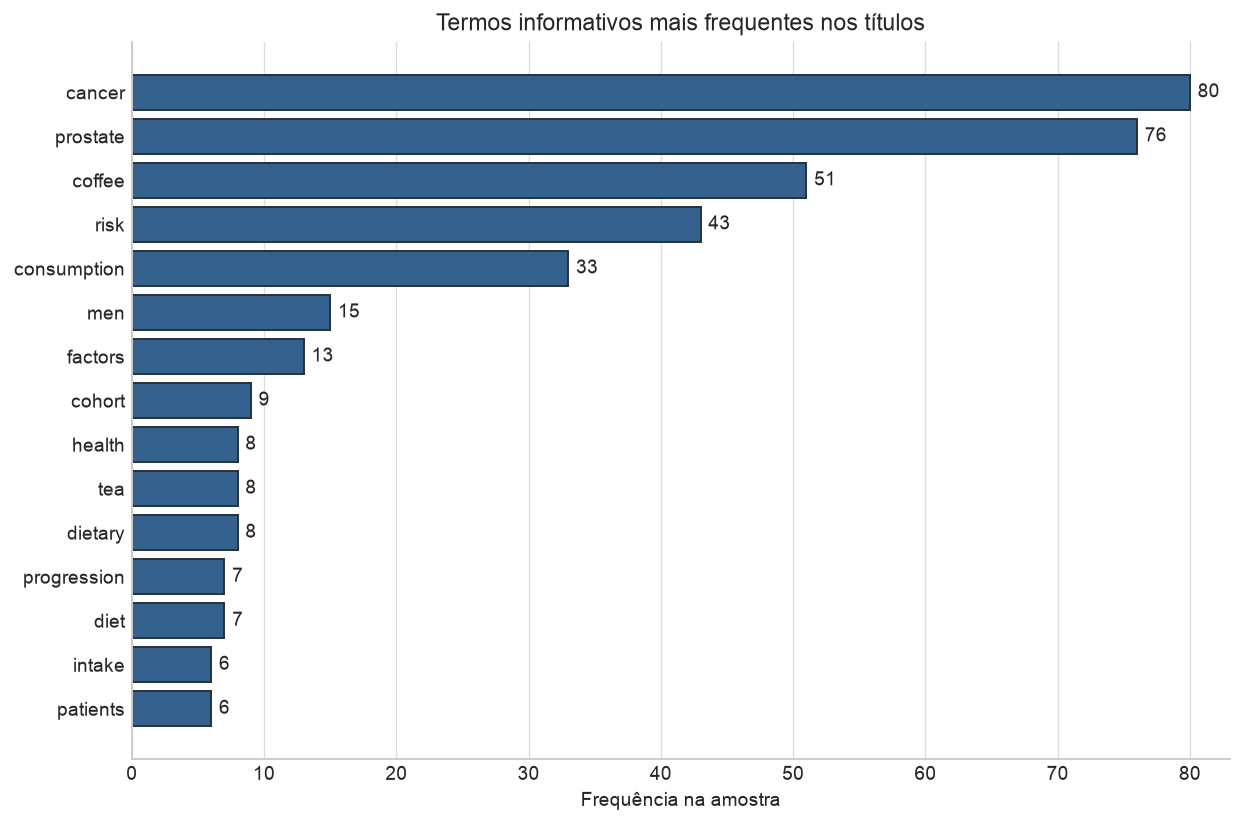

Top termos: [('cancer', 80), ('prostate', 76), ('coffee', 51), ('risk', 43), ('consumption', 33), ('men', 15), ('factors', 13), ('cohort', 9), ('health', 8), ('tea', 8), ('dietary', 8), ('progression', 7), ('diet', 7), ('intake', 6), ('patients', 6)]


In [10]:
STOPWORDS = {
    'a', 'an', 'and', 'are', 'as', 'at', 'be', 'by', 'for', 'from', 'in', 'is',
    'of', 'on', 'or', 'the', 'to', 'with', 'among', 'between', 'study', 'studies',
    'analysis', 'review', 'systematic', 'meta', 'based', 'association', 'associations',
}
tokens = [
    token
    for row in rows
    for token in re.findall(r"[a-z]+", row['title'].casefold())
    if len(token) > 2 and token not in STOPWORDS
]
top_terms = Counter(tokens).most_common(15)
terms = [term for term, _ in top_terms][::-1]
frequencies = [count for _, count in top_terms][::-1]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(terms, frequencies, color=COLORS['primary'], edgecolor='#263238')
ax.bar_label(bars, padding=4)
ax.set_title('Termos informativos mais frequentes nos títulos')
ax.set_xlabel('Frequência na amostra')
ax.set_xlim(0, max(frequencies) + 3)
ax.grid(axis='x', color='#d9dee3', linewidth=0.7)
ax.grid(axis='y', visible=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
display_figure(fig, 'Quinze termos informativos mais frequentes nos títulos.')

print('Top termos:', top_terms)

## Takeaways

1. **Cobertura:** foram coletados **100 de 116 registros** da consulta (**86,2%**), ordenados por relevância; os resultados não constituem um censo da literatura.
2. **Qualidade estrutural:** não há PMIDs nem títulos normalizados duplicados; todos os registros têm ano e URL, **93% têm DOI** e dois registros não informam autores.
3. **Amplitude temporal:** a amostra vai de **1964 a 2026**, com maior frequência em **2013 (9 artigos)**. Comparações por ano devem considerar o pequeno volume e a seleção por relevância.
4. **Concentração editorial:** os dez periódicos mais frequentes reúnem **38%** dos registros, indicando dispersão por muitas fontes.
5. **Conteúdo textual:** os títulos têm mediana de **14 palavras**; os termos dominantes são `cancer`, `prostate`, `coffee`, `risk` e `consumption`, coerentes com a consulta.
6. **Risco de relevância:** somente **39 títulos** mencionam café e próstata simultaneamente; **12 não mencionam nenhum dos conceitos no título**. Resultados periféricos devem ser filtrados com resumo, MeSH e ranking híbrido antes do RAG.
7. **Natureza do dataset:** não há rótulo de veracidade, apoio ou contradição. O corpus serve como fonte documental, mas um conjunto anotado e revisado por humanos será necessário para avaliar classificação de evidências.

## Checks

As verificações abaixo confirmam o grão, a rastreabilidade, os limites de validade e a consistência das métricas exibidas.

In [11]:
assert rows, 'A coleta não pode estar vazia.'
assert len(rows) <= MAX_RECORDS
assert len(rows) == metadata['records_captured']
assert metadata['query'] == QUERY
assert duplicate_pmids == 0
assert not invalid_years
assert not invalid_urls
assert sum(year_counts.values()) + missing_counts['year'] == len(rows)
assert sum(journal_counts.values()) == len(rows)
assert sum(count for _, count in Counter(tokens).items()) == len(tokens)

eda_summary = {
    'records': len(rows),
    'total_pubmed_matches': metadata['total_matches'],
    'sample_coverage': round(coverage, 4),
    'year_range': [min(years), max(years)] if years else None,
    'peak_year': max(year_counts, key=year_counts.get) if year_counts else None,
    'peak_year_records': max(year_counts.values()) if year_counts else 0,
    'doi_completeness': round(completeness['doi'], 4),
    'duplicate_pmids': duplicate_pmids,
    'duplicate_titles': duplicate_titles,
    'title_topic_groups': dict(title_topic_counts),
    'top_10_journal_share': round(top_10_share, 4),
    'median_title_words': median(title_lengths),
    'top_terms': top_terms[:5],
}
print(json.dumps(eda_summary, ensure_ascii=False, indent=2))
print('EDA validada: métricas reconciliadas, gráficos gerados e fontes rastreáveis.')

{
  "records": 100,
  "total_pubmed_matches": 116,
  "sample_coverage": 0.8621,
  "year_range": [
    1964,
    2026
  ],
  "peak_year": 2013,
  "peak_year_records": 9,
  "doi_completeness": 0.93,
  "duplicate_pmids": 0,
  "duplicate_titles": 0,
  "title_topic_groups": {
    "Nenhum no título": 12,
    "Somente próstata": 35,
    "Café e próstata": 39,
    "Somente café": 14
  },
  "top_10_journal_share": 0.38,
  "median_title_words": 14.0,
  "top_terms": [
    [
      "cancer",
      80
    ],
    [
      "prostate",
      76
    ],
    [
      "coffee",
      51
    ],
    [
      "risk",
      43
    ],
    [
      "consumption",
      33
    ]
  ]
}
EDA validada: métricas reconciliadas, gráficos gerados e fontes rastreáveis.
